# YOLO26 Dataset Preparation: Convert Polygon-Like Labels To Boxes

This notebook performs one step only: prepare detection labels.

Current dataset state:
- `training_yolo26/` is the train/val/test split created from `VSAM.yolo26`.
- Some labels are already normal YOLO boxes: `class x_center y_center width height`.
- Some labels contain many coordinates. That can happen when Roboflow exports mask/auto-label geometry even if the project is intended for bounding-box detection.

Goal:
- Keep `training_yolo26/` unchanged.
- Create `training_yolo26_boxes/`.
- Copy images unchanged.
- Convert every label row to standard YOLO detection boxes.
- Draw visual checks before and after conversion.

Why this matters:
- Detection training expects 5-column YOLO labels.
- Long polygon rows can be converted safely by taking the min/max x/y extent of the polygon.
- Keeping a separate output folder means we can inspect and delete/rebuild it without losing the original export split.

## 1. Configure Paths

Run this first. It works whether Jupyter starts in `detection_model/` or `detection_model/notebooks/`.

In [1]:
from pathlib import Path
import random
import shutil
from collections import Counter

import cv2
import matplotlib.pyplot as plt
import yaml

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

SOURCE_DATASET = PROJECT_ROOT / "training_yolo26"
BOX_DATASET = PROJECT_ROOT / "training_yolo26_boxes"
REBUILD_BOX_DATASET = True
SPLITS = ["train", "val", "test"]
SEED = 42
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

print("Project root:", PROJECT_ROOT)
print("Source dataset:", SOURCE_DATASET)
print("Converted box dataset:", BOX_DATASET)

if not SOURCE_DATASET.exists():
    raise FileNotFoundError(f"Missing source split folder: {SOURCE_DATASET}")

Project root: C:\Users\Hecos\Documents\sem\industry\vslam\code\detection_model
Source dataset: C:\Users\Hecos\Documents\sem\industry\vslam\code\detection_model\training_yolo26
Converted box dataset: C:\Users\Hecos\Documents\sem\industry\vslam\code\detection_model\training_yolo26_boxes


## 2. Load Class Metadata

This reads class names from `training_yolo26/data.yaml`. The converted folder will get a new `data.yaml` pointing to `training_yolo26_boxes/`.

In [2]:
source_yaml_path = SOURCE_DATASET / "data.yaml"
with source_yaml_path.open("r", encoding="utf-8") as f:
    source_yaml = yaml.safe_load(f) or {}

class_names = source_yaml.get("names")
if isinstance(class_names, dict):
    class_names = [class_names[i] for i in sorted(class_names)]

if not class_names:
    raise ValueError("Could not read class names from training_yolo26/data.yaml")

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Classes: ['Human']
Number of classes: 1


## 3. Conversion Helpers

For a standard box row, the values are kept as-is.

For a long polygon row, the code computes the smallest axis-aligned bounding box that contains all polygon points:

- `x_min = min(all x points)`
- `x_max = max(all x points)`
- `y_min = min(all y points)`
- `y_max = max(all y points)`
- then converts that to YOLO `x_center y_center width height`.

In [3]:
def clamp01(value: float) -> float:
    return max(0.0, min(1.0, value))


def polygon_to_box(values):
    """Convert normalized polygon coordinates to normalized YOLO xywh."""
    xs = values[0::2]
    ys = values[1::2]
    x_min = clamp01(min(xs))
    x_max = clamp01(max(xs))
    y_min = clamp01(min(ys))
    y_max = clamp01(max(ys))
    width = x_max - x_min
    height = y_max - y_min
    x_center = x_min + width / 2
    y_center = y_min + height / 2
    return [x_center, y_center, width, height]


def parse_label_line(line: str, label_path: Path, line_number: int):
    parts = line.strip().split()
    if not parts:
        return None
    if len(parts) < 5:
        raise ValueError(f"{label_path}:{line_number} has fewer than 5 columns")

    class_id = int(float(parts[0]))
    values = [float(v) for v in parts[1:]]

    if class_id < 0 or class_id >= len(class_names):
        raise ValueError(f"{label_path}:{line_number} class {class_id} is outside class range")
    if any(v < 0 or v > 1 for v in values):
        raise ValueError(f"{label_path}:{line_number} has non-normalized coordinates")

    if len(values) == 4:
        box = values
        source_type = "box"
    else:
        if len(values) % 2 != 0:
            raise ValueError(f"{label_path}:{line_number} polygon has an odd number of coordinates")
        box = polygon_to_box(values)
        source_type = "polygon"

    if box[2] <= 0 or box[3] <= 0:
        raise ValueError(f"{label_path}:{line_number} converted box has zero area")

    return class_id, box, values, source_type


def read_label(label_path: Path):
    rows = []
    with label_path.open("r", encoding="utf-8") as f:
        for line_number, line in enumerate(f, start=1):
            parsed = parse_label_line(line, label_path, line_number)
            if parsed is not None:
                rows.append(parsed)
    return rows


def format_box_row(class_id: int, box):
    return f"{class_id} " + " ".join(f"{clamp01(v):.8f}" for v in box)

## 4. Inspect Label Types

This does not modify files. It counts how many rows are already boxes and how many will be converted from polygon-style rows.

In [4]:
label_type_counts = Counter()
split_image_counts = Counter()
split_object_counts = Counter()

for split in SPLITS:
    image_dir = SOURCE_DATASET / "images" / split
    label_dir = SOURCE_DATASET / "labels" / split
    images = sorted(p for p in image_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS)
    split_image_counts[split] = len(images)

    for image_path in images:
        label_path = label_dir / f"{image_path.stem}.txt"
        if not label_path.exists():
            raise FileNotFoundError(f"Missing label for {image_path.name}: {label_path}")
        rows = read_label(label_path)
        split_object_counts[split] += len(rows)
        for _, _, _, source_type in rows:
            label_type_counts[source_type] += 1

print("Images by split:", dict(split_image_counts))
print("Objects by split:", dict(split_object_counts))
print("Input label row types:", dict(label_type_counts))

Images by split: {'train': 389, 'val': 111, 'test': 57}
Objects by split: {'train': 581, 'val': 167, 'test': 79}
Input label row types: {'polygon': 636, 'box': 191}


## 5. Visual Check Before Writing

This compares original label geometry with the box that will be written.

Color meaning:
- Yellow: original polygon from the source label.
- Blue: original row was already a YOLO box.
- Red: converted detection box that will be written.

If the red boxes look wrong, stop here and adjust before creating `training_yolo26_boxes/`.

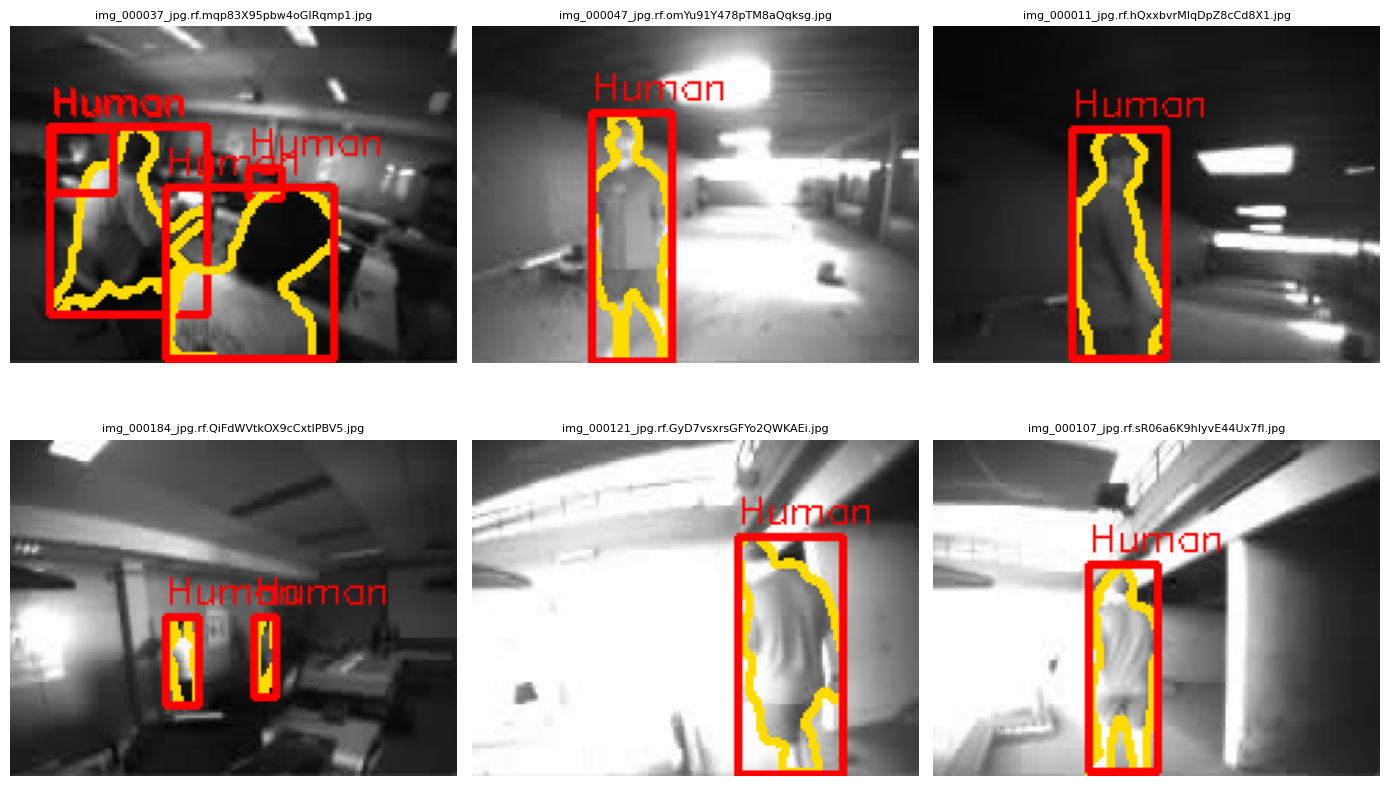

In [5]:
def draw_pre_conversion_check(image_path: Path, label_path: Path):
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f"Could not read {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    for class_id, box, original_values, source_type in read_label(label_path):
        if source_type == "polygon":
            points = []
            for i in range(0, len(original_values), 2):
                points.append([int(original_values[i] * w), int(original_values[i + 1] * h)])
            import numpy as np
            pts = np.array(points, dtype=np.int32)
            cv2.polylines(image, [pts], isClosed=True, color=(255, 220, 0), thickness=2)
        else:
            xc, yc, bw, bh = original_values
            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 120, 255), 2)

        xc, yc, bw, bh = box
        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)
        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(image, class_names[class_id], (x1, max(y1 - 5, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 0), 1)

    return image


all_pairs = []
polygon_pairs = []
for split in SPLITS:
    image_dir = SOURCE_DATASET / "images" / split
    label_dir = SOURCE_DATASET / "labels" / split
    for image_path in sorted(image_dir.iterdir()):
        if image_path.suffix.lower() not in IMAGE_EXTS:
            continue
        label_path = label_dir / f"{image_path.stem}.txt"
        rows = read_label(label_path)
        pair = (image_path, label_path)
        all_pairs.append(pair)
        if any(row[3] == "polygon" for row in rows):
            polygon_pairs.append(pair)

sample_source = polygon_pairs if polygon_pairs else all_pairs
sample = random.Random(SEED).sample(sample_source, k=min(6, len(sample_source)))

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, (image_path, label_path) in zip(axes.ravel(), sample):
    ax.imshow(draw_pre_conversion_check(image_path, label_path))
    ax.set_title(image_path.name, fontsize=8)
    ax.axis("off")
plt.tight_layout()

## 6. Write Converted Detection Dataset

Run this only after the visual check looks correct.

This creates `training_yolo26_boxes/` with the same split as `training_yolo26/`. Every output label row is standard YOLO detection format.

In [7]:
if BOX_DATASET.exists():
    if REBUILD_BOX_DATASET:
        shutil.rmtree(BOX_DATASET)
    else:
        raise FileExistsError(f"Converted dataset already exists: {BOX_DATASET}")

write_counts = Counter()

for split in SPLITS:
    source_image_dir = SOURCE_DATASET / "images" / split
    source_label_dir = SOURCE_DATASET / "labels" / split
    target_image_dir = BOX_DATASET / "images" / split
    target_label_dir = BOX_DATASET / "labels" / split
    target_image_dir.mkdir(parents=True, exist_ok=True)
    target_label_dir.mkdir(parents=True, exist_ok=True)

    for image_path in sorted(source_image_dir.iterdir()):
        if image_path.suffix.lower() not in IMAGE_EXTS:
            continue

        source_label_path = source_label_dir / f"{image_path.stem}.txt"
        target_label_path = target_label_dir / source_label_path.name

        shutil.copy2(image_path, target_image_dir / image_path.name)

        rows = read_label(source_label_path)
        with target_label_path.open("w", encoding="utf-8") as f:
            for class_id, box, _, source_type in rows:
                f.write(format_box_row(class_id, box) + "\n")
                write_counts[source_type] += 1
        write_counts[f"{split}_images"] += 1

data_yaml = {
    "path": BOX_DATASET.resolve().as_posix(),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": len(class_names),
    "names": class_names,
}
with (BOX_DATASET / "data.yaml").open("w", encoding="utf-8") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print("Created:", BOX_DATASET)
print("Rows converted/written:", dict(write_counts))
print((BOX_DATASET / "data.yaml").read_text(encoding="utf-8"))

Created: C:\Users\Hecos\Documents\sem\industry\vslam\code\detection_model\training_yolo26_boxes
Rows converted/written: {'polygon': 636, 'train_images': 389, 'box': 191, 'val_images': 111, 'test_images': 57}
path: C:/Users/Hecos/Documents/sem/industry/vslam/code/detection_model/training_yolo26_boxes
train: images/train
val: images/val
test: images/test
nc: 1
names:
- Human



## 7. Visual Check After Conversion

This reads from `training_yolo26_boxes/` and draws only final detection boxes. Use this to confirm the written labels look ready for training.

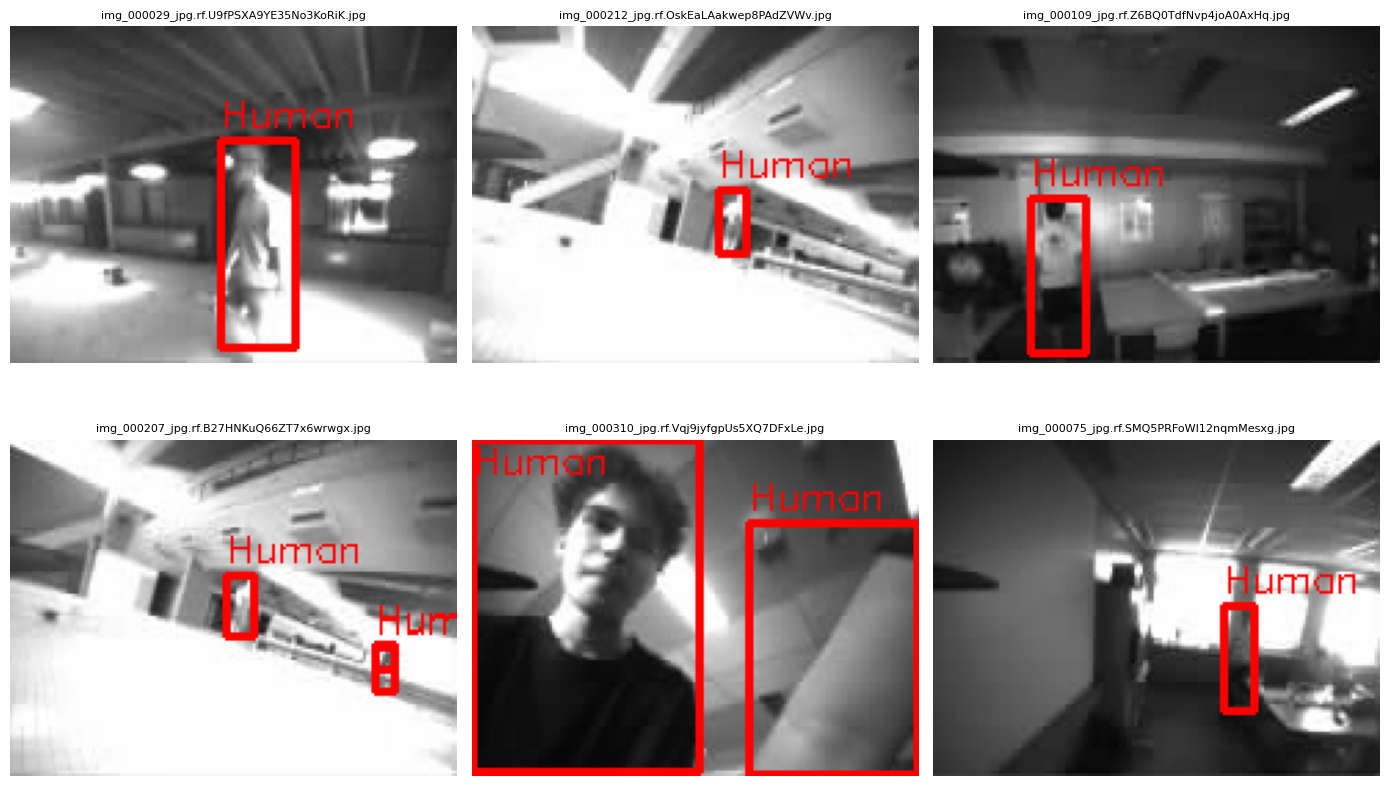

In [8]:
def draw_converted_boxes(image_path: Path, label_path: Path):
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f"Could not read {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    h, w = image.shape[:2]

    for class_id, box, _, _ in read_label(label_path):
        xc, yc, bw, bh = box
        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)
        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(image, class_names[class_id], (x1, max(y1 - 5, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 0), 1)

    return image


converted_pairs = []
for split in SPLITS:
    image_dir = BOX_DATASET / "images" / split
    label_dir = BOX_DATASET / "labels" / split
    for image_path in sorted(image_dir.iterdir()):
        if image_path.suffix.lower() in IMAGE_EXTS:
            converted_pairs.append((image_path, label_dir / f"{image_path.stem}.txt"))

sample = random.Random(SEED + 1).sample(converted_pairs, k=min(6, len(converted_pairs)))
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, (image_path, label_path) in zip(axes.ravel(), sample):
    ax.imshow(draw_converted_boxes(image_path, label_path))
    ax.set_title(image_path.name, fontsize=8)
    ax.axis("off")
plt.tight_layout()

## 8. Train YOLO26n Detection Baseline

This step trains `yolo26n.pt` on the converted bounding-box dataset `training_yolo26_boxes/`.

The model is already the smallest YOLO26 detection checkpoint (`n` = nano). To make CPU training smaller and faster, reduce the training image size instead of changing the model family.

Why these settings:

- `yolo26n.pt`: smallest YOLO26 detection model, best first choice for CPU training and later real-time use.
- `AUTO_IMGSZ`: checks the real dataset image sizes and chooses a stride-safe size. If your images are around 200x200, it uses `224`; otherwise it uses `320` for medium small frames.
- `epochs=80` with `patience=20`: shorter CPU baseline. Increase later only if the curves still improve.
- `batch=8`: fixed small CPU batch. `batch=-1` is mostly useful for CUDA AutoBatch and may fall back noisily on CPU.
- `workers=0`: safer on Windows/Jupyter; avoids common multiprocessing issues.
- `hsv_h=0.0` and `hsv_s=0.0`: the images are grayscale/IR-like, so hue and saturation augmentation are not useful.
- `hsv_v=0.25`: brightness changes are useful because the camera has strong exposure variation.
- `degrees=0.0` and `shear=0.0`: people should stay upright; heavy geometric distortion can hurt detection.
- `close_mosaic=5`: keeps mosaic augmentation early, then disables it near the end so final training sees more natural images.

Run the image-size/config cells first. Run the training cell only when the printed paths and chosen `imgsz` look correct.


In [ ]:
TRAIN_DATA = BOX_DATASET / "data.yaml"
RUNS_DIR = PROJECT_ROOT / "runs" / "yolo26"
TRAIN_NAME = "yolo26n_human_boxes_cpu_small"

def collect_image_sizes(dataset_root: Path, splits):
    sizes = Counter()
    examples = []
    for split in splits:
        image_dir = dataset_root / "images" / split
        for image_path in sorted(image_dir.iterdir()):
            if image_path.suffix.lower() not in IMAGE_EXTS:
                continue
            image = cv2.imread(str(image_path))
            if image is None:
                raise ValueError(f"Could not read image: {image_path}")
            h, w = image.shape[:2]
            sizes[(w, h)] += 1
            if len(examples) < 5:
                examples.append((image_path.name, w, h))
    return sizes, examples

image_sizes, size_examples = collect_image_sizes(BOX_DATASET, SPLITS)
max_side = max(max(width, height) for width, height in image_sizes)

# YOLO image sizes should be multiples of 32. 224 is the closest small choice for ~200x200 images.
AUTO_IMGSZ = 224 if max_side <= 224 else 320

print("Dataset image sizes:")
for (width, height), count in image_sizes.most_common():
    print(f"  {width}x{height}: {count} images")
print("Examples:", size_examples)
print("Max side:", max_side)
print("Chosen CPU training imgsz:", AUTO_IMGSZ)

TRAIN_ARGS = {
    "data": str(TRAIN_DATA),
    "epochs": 80,
    "imgsz": AUTO_IMGSZ,
    "batch": 8,
    "patience": 20,
    "workers": 0,
    "device": "cpu",
    "cache": False,
    "optimizer": "auto",
    "cos_lr": True,
    "close_mosaic": 5,
    "mosaic": 0.6,
    "scale": 0.35,
    "translate": 0.08,
    "degrees": 0.0,
    "shear": 0.0,
    "fliplr": 0.5,
    "hsv_h": 0.0,
    "hsv_s": 0.0,
    "hsv_v": 0.25,
    "project": str(RUNS_DIR),
    "name": TRAIN_NAME,
    "exist_ok": True,
    "seed": SEED,
    "deterministic": True,
    "plots": True,
    "val": True,
    "save": True,
}

print("Training data:", TRAIN_DATA)
print("Training output:", RUNS_DIR / TRAIN_NAME)
print("Model: yolo26n.pt")
print("Training args:")
for key, value in TRAIN_ARGS.items():
    print(f"  {key}: {value}")

if not TRAIN_DATA.exists():
    raise FileNotFoundError(f"Missing converted dataset YAML: {TRAIN_DATA}")


In [ ]:
from ultralytics import YOLO

# This downloads yolo26n.pt on first use if it is not already cached.
model = YOLO("yolo26n.pt")
results = model.train(**TRAIN_ARGS)

## 9. Validate Best Checkpoint

After training, validate the best saved checkpoint on the test split. This reports final detection metrics on images that were not used for training or validation.

In [ ]:
best_weights = RUNS_DIR / TRAIN_NAME / "weights" / "best.pt"
print("Best weights:", best_weights)

best_model = YOLO(str(best_weights))
test_metrics = best_model.val(data=str(TRAIN_DATA), split="test", imgsz=TRAIN_ARGS["imgsz"], plots=True)
print(test_metrics)

## 10. Compare Pretrained And Retrained Models

This compares the original pretrained `yolo26n.pt` with your retrained `best.pt`.

Important detail: COCO pretrained YOLO uses class `person`, while your dataset class is `Human`. Both are class index `0`, so metric validation can be useful as a rough comparison, but the visual comparison is the most important check.

Use this to answer: did retraining improve detections on your drone camera images, or did it overfit / miss people?


In [ ]:
from ultralytics import YOLO

pretrained_model = YOLO("yolo26n.pt")
retrained_model = YOLO(str(best_weights))

print("Validating pretrained model on test split...")
pretrained_metrics = pretrained_model.val(
    data=str(TRAIN_DATA),
    split="test",
    imgsz=TRAIN_ARGS["imgsz"],
    device="cpu",
    workers=0,
    plots=False,
)

print("Validating retrained model on test split...")
retrained_metrics = retrained_model.val(
    data=str(TRAIN_DATA),
    split="test",
    imgsz=TRAIN_ARGS["imgsz"],
    device="cpu",
    workers=0,
    plots=False,
)

print("Pretrained metrics:", pretrained_metrics)
print("Retrained metrics:", retrained_metrics)


In [ ]:
def draw_predictions(image_path: Path, model, title: str, imgsz: int, conf: float = 0.25):
    result = model.predict(
        source=str(image_path),
        imgsz=imgsz,
        conf=conf,
        device="cpu",
        verbose=False,
    )[0]
    plotted = result.plot()
    plotted = cv2.cvtColor(plotted, cv2.COLOR_BGR2RGB)
    return plotted, title

test_image_dir = BOX_DATASET / "images" / "test"
test_images = [p for p in sorted(test_image_dir.iterdir()) if p.suffix.lower() in IMAGE_EXTS]
sample_images = random.Random(SEED + 2).sample(test_images, k=min(4, len(test_images)))

fig, axes = plt.subplots(len(sample_images), 2, figsize=(10, 4 * len(sample_images)))
if len(sample_images) == 1:
    axes = [axes]

for row_axes, image_path in zip(axes, sample_images):
    pretrained_plot, pretrained_title = draw_predictions(image_path, pretrained_model, "Pretrained yolo26n.pt", TRAIN_ARGS["imgsz"])
    retrained_plot, retrained_title = draw_predictions(image_path, retrained_model, "Retrained best.pt", TRAIN_ARGS["imgsz"])

    row_axes[0].imshow(pretrained_plot)
    row_axes[0].set_title(f"{pretrained_title} | {image_path.name}", fontsize=8)
    row_axes[0].axis("off")

    row_axes[1].imshow(retrained_plot)
    row_axes[1].set_title(f"{retrained_title} | {image_path.name}", fontsize=8)
    row_axes[1].axis("off")

plt.tight_layout()
